# Public-transport weekday stop frequencies

This notebook combines the legacy school-day/holiday weekday extracts through 2020 with annual Mobilitätsverbünde Österreich GTFS feeds from 2021 onward. Separate ÖBB GTFS feeds supplement the missing ÖBB-operated rail services: the observed annual ÖBB archive is used in 2023–2025, while the earliest available ÖBB archive (2023) is explicitly reused as a proxy for 2021 and 2022. GTFS weekday frequency is calculated from `trips.txt`, `stop_times.txt`, `calendar.txt`, and `calendar_dates.txt`; platform-level GTFS records are aggregated to the stable `at:46:<station>` identifier before sources are merged. Stops are restricted to the dissolved official Styria municipality boundary before annual datasets are validated and exported.

The original 2016 school-day export is incomplete. It contains 2,542 stops and 122,746 departures, while the 2017 school-day export contains 7,519 stops and 247,073 departures. Datei 3 contains exactly the same limited records as Datei 1, so this is a source-data problem rather than a parser or coordinate-matching problem. The analysis therefore uses the complete 2017 layer as the explicit proxy for both 2015 (which has no source) and 2016. The complete 2015–2025 year assignment is made here, so downstream notebooks only read the already prepared file for their target year.


In [57]:
import os
import sys
from pathlib import Path
from zipfile import ZipFile

os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
sys.path.insert(0, str(Path.cwd() / "FIG"))
from plotting.apa7 import add_north_arrow, new_figure, save_apa7, set_apa7_style

DATA_DIR = Path("OGD/Public_Transport/Verbund_Daten_work")
GTFS_DIR = Path("OGD/Public_Transport/Verbund_Linie_GTFS")
OUTPUT_DIR = Path("OGD/Public_Transport")
FIGURE_DIR = Path("FIG/Haltestellen")
BOUNDARY_PATH = Path("OGD/Gemeindegrenzen.zip")
LEGACY_SOURCE_YEARS = (2016, 2017, 2018, 2019, 2020, 2022)
VALID_LEGACY_YEARS = (2017, 2018, 2019, 2020, 2022)
GTFS_SOURCE_YEARS = (2021, 2022, 2023, 2024, 2025)
OBB_ARCHIVE_YEARS = (2023, 2024, 2025)
OBB_SUPPLEMENT_SOURCE_YEAR = {2021: 2023, 2022: 2023, 2023: 2023, 2024: 2024, 2025: 2025}
OBB_AGENCY_IDS = {"01"}  # ÖBB Personenverkehr; exclude unrelated national-feed operators.
MIN_WEEKDAY_DEPARTURES = 0
SOURCE_LABELS = {"legacy": "Verkehrsverbund Steiermark", "gtfs": "Mobilitätsverbünde Österreich"}
GTFS_REPRESENTATIVE_DATES = {
    # Ferienfenster: Werktage der Herbstferien (27.10.-31.10.) plus 2.11. (schulfrei, kein Feiertag).
    # 1.11. (Allerheiligen) ist ausgenommen: gesetzlicher Feiertag mit Sonntagsfahrplan.
    2021: {
        "school": ["2021-10-18", "2021-10-19", "2021-10-20", "2021-10-21", "2021-10-22"],
        "holiday": ["2021-10-27", "2021-10-28", "2021-10-29", "2021-11-02"],  # Mi Do Fr Di
    },
    2022: {
        "school": ["2022-10-17", "2022-10-18", "2022-10-19", "2022-10-20", "2022-10-21"],
        "holiday": ["2022-10-27", "2022-10-28", "2022-10-31", "2022-11-02"],  # Do Fr Mo Mi
    },
    2023: {
        "school": ["2023-10-16", "2023-10-17", "2023-10-18", "2023-10-19", "2023-10-20"],
        "holiday": ["2023-10-27", "2023-10-30", "2023-10-31", "2023-11-02"],  # Fr Mo Di Do
    },
    2024: {
        "school": ["2024-10-21", "2024-10-22", "2024-10-23", "2024-10-24", "2024-10-25"],
        "holiday": ["2024-10-28", "2024-10-29", "2024-10-30", "2024-10-31"],  # Mo Di Mi Do
        # 2.11.2024 faellt auf Samstag und entfaellt.
    },
    2025: {
        "school": ["2025-10-20", "2025-10-21", "2025-10-22", "2025-10-23", "2025-10-24"],
        "holiday": ["2025-10-27", "2025-10-28", "2025-10-29", "2025-10-30", "2025-10-31"],  # Mo bis Fr
        # 1.11.2025 Samstag, 2.11.2025 Sonntag, beide entfallen ohnehin.
    },
}
CORE_GTFS_COMPONENTS = [
    ("mvo", "94", "3"),  # RegioBus Steiermark
    ("mvo", "38", "3"),  # Graz Linien bus
    ("mvo", "33", "0"),  # Graz Linien tram
    ("mvo", "52", "3"),  # Mürztaler Verkehrsgesellschaft
    ("mvo", "53", "3"),  # Stadtwerke Leoben
    ("mvo", "36", "2"),  # Steiermarkbahn rail
    ("mvo", "37", "2"),  # GKB rail
]
ANALYSIS_YEARS = tuple(range(2015, 2026))
YEAR_ASSIGNMENTS = {
    2015: ("legacy", 2017, "full_2017_proxy"),
    2016: ("legacy", 2017, "full_2017_proxy"),
    **{year: ("legacy", year, "observed_legacy") for year in range(2017, 2021)},
    2021: ("gtfs", 2021, "observed_gtfs_with_obb_2023_proxy"),
    2022: ("gtfs", 2022, "observed_gtfs_with_obb_2023_proxy"),
    **{year: ("gtfs", year, "observed_gtfs_with_obb") for year in range(2023, 2026)},
}
EFA_PREFIX = 63_200_000
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
set_apa7_style()


In [58]:
def read_frequency_csv(path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(path, encoding=encoding, dtype={"EFA-Haltestellennummer": "string"})
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Could not decode {path}")


def source_file(year, day_type, table_number=1):
    pattern = f"Manfred_Brandl_stv-{year}*/**/Montag-Freitag-{day_type}_*.Datei{table_number}_ab.csv"
    files = list(DATA_DIR.glob(pattern))
    if len(files) != 1:
        raise FileNotFoundError(f"Expected one source file for {year} {day_type}; found {files}")
    return files[0]


def frequency_table(year, day_type, departure_column):
    table = read_frequency_csv(source_file(year, day_type)).rename(columns={
        "EFA-Haltestellennummer": "efa_stop_id",
        "GlobalID": "global_id",
        "Haltestellenname mit Ort": "station_name",
        "Anzahl Abfahrten": departure_column,
    })
    table["efa_stop_id"] = pd.to_numeric(table["efa_stop_id"], errors="raise").astype("int64")
    table["station_id"] = table["efa_stop_id"] - EFA_PREFIX
    table[departure_column] = pd.to_numeric(table[departure_column], errors="raise")
    return table[["station_id", "efa_stop_id", "global_id", "station_name", departure_column]]


def weekday_line_table(year):
    tables = []
    for day_type in ("Schule", "Ferien"):
        lines = read_frequency_csv(source_file(year, day_type, table_number=2))
        line_key_column = next(column for column in lines.columns if column.startswith("Linienschl"))
        lines = lines.rename(columns={
            "EFA-Haltestellennummer": "efa_stop_id",
            "Linientext": "line_name",
            line_key_column: "line_key",
        })[["efa_stop_id", "line_key", "line_name"]]
        lines["efa_stop_id"] = pd.to_numeric(lines["efa_stop_id"], errors="raise").astype("int64")
        lines["station_id"] = lines["efa_stop_id"] - EFA_PREFIX
        lines["line_name"] = lines["line_name"].astype("string").str.strip()
        lines["route_id"] = lines["line_key"].astype("string").str.strip().str.replace(r"\..*$", "", regex=True)
        missing_route_id = lines["route_id"].isna() | lines["route_id"].eq("")
        lines.loc[missing_route_id, "route_id"] = "TEXT:" + lines.loc[missing_route_id, "line_name"].str.upper().str.replace(r"\s+", "", regex=True)
        tables.append(lines.dropna(subset=["line_name"]))

    station_lines = pd.concat(tables, ignore_index=True)
    station_lines = station_lines[station_lines["line_name"].ne("")]
    line_counts = (station_lines.drop_duplicates(["station_id", "line_name"])
                   .groupby("station_id", as_index=False).size()
                   .rename(columns={"size": "weekday_line_count"}))
    route_ids = (station_lines.drop_duplicates(["station_id", "route_id"])
                 .groupby("station_id")["route_id"]
                 .agg(lambda values: "|".join(sorted(values)))
                 .rename("weekday_route_ids").reset_index())
    return line_counts.merge(route_ids, on="station_id", how="outer", validate="one_to_one")


## Styria boundary and stop locations

The official municipality polygons are dissolved into one Styria boundary. The location reference is filtered immediately, and the boundary is enforced again after each annual frequency table is joined to its coordinates. Boundary points are retained.


In [59]:
municipality_boundaries = gpd.read_file(
    BOUNDARY_PATH, layer="Gemeindegrenzen", columns=["GEMNR"]
).to_crs("EPSG:3857")
styria_boundary = (
    municipality_boundaries.geometry.union_all()
    if hasattr(municipality_boundaries.geometry, "union_all")
    else municipality_boundaries.geometry.unary_union
)

locations = pd.read_excel(DATA_DIR / "Manfred_Brandl_Haltestellen-Mangurano.xlsx", sheet_name="Haltestellen")
locations = locations.rename(columns={
    "Nummer": "station_id",
    "Name mit Ort": "station_name_location_file",
    "MRCV-x": "x_web_mercator",
    "MRCV-y2": "y_web_mercator",
})[["station_id", "station_name_location_file", "x_web_mercator", "y_web_mercator"]]
locations["station_id"] = pd.to_numeric(locations["station_id"], errors="raise").astype("int64")
locations[["x_web_mercator", "y_web_mercator"]] = locations[["x_web_mercator", "y_web_mercator"]].apply(pd.to_numeric, errors="coerce")
locations = locations.dropna(subset=["x_web_mercator", "y_web_mercator"]).reset_index(drop=True)
location_count_before_boundary = len(locations)
location_geometry = gpd.GeoSeries(
    gpd.points_from_xy(locations["x_web_mercator"], locations["y_web_mercator"]),
    crs="EPSG:3857",
)
locations = locations.loc[location_geometry.intersects(styria_boundary)].reset_index(drop=True)

print(f"Located stops inside Styria: {len(locations):,}")
print(f"Located stops removed outside Styria: {location_count_before_boundary - len(locations):,}")
display(locations.head())
display(locations[["x_web_mercator", "y_web_mercator"]].describe().round(1))


Located stops inside Styria: 10,248
Located stops removed outside Styria: 9


,station_id,station_name_location_file,x_web_mercator,y_web_mercator
0,1,Voitsberg Josefskirche,1685862,5950405
1,2,Voitsberg Hauptplatz,1686518,5950126
2,3,Voitsberg Hauptschule,1686809,5949442
3,4,Arnstein Gustibar,1686924,5948687
4,5,Arnstein Koppn Kapelle,1688678,5947287


,x_web_mercator,y_web_mercator
count,10248.0,10248.0
mean,1705663.9,5967709.4
std,65377.7,41321.3
min,1511169.0,5883162.0
25%,1686919.0,5941359.0
50%,1718836.0,5963868.5
75%,1753846.0,6003045.5
max,1796812.0,6075805.0


## GTFS weekday-frequency method

A GTFS `stop_times.txt` row is a scheduled departure when `departure_time` is present and `pickup_type` is not 1 (no pickup). Each row is linked through `trips.txt` to its route and service. `calendar.txt` plus `calendar_dates.txt` determine whether that trip operates on ten explicitly selected dates: five consecutive Monday–Friday school days immediately before the autumn break and five official school-free weekdays during the Austrian autumn-holiday period (including 1 November and, where needed, the generally school-free 2 November). Departures are averaged within each five-day period, and `weekday_avg_departures` is the equal-weight mean of the school-period and holiday-period averages. The exact dates are stored in `GTFS_REPRESENTATIVE_DATES`; using October/early November keeps the two day types close together and, unlike the incomplete summer windows in some archives, gives 100% coverage of the stable core operator/mode components in every export. The monthly completeness diagnostic and Figure 4d make this validation explicit. Only agency `01` (ÖBB Personenverkehr) is selected from the national ÖBB archives. Observed ÖBB data are available for 2023–2025; because the primary MVO exports also omit ÖBB in 2021 and 2022, the complete 2023 ÖBB school/holiday averages and stations are reused for those two target years as an explicitly labelled proxy. ÖBB route IDs receive an `OBB:` namespace before being combined with the primary feed; shared station IDs receive added frequencies but retain their primary name, coordinates, and geometry, while genuinely missing station IDs are appended from the ÖBB feed. Stops below one average departure per workday are retained for diagnostics and Figure 7c, but excluded from every final annual layer.


In [60]:
def gtfs_file(year):
    files = list(GTFS_DIR.glob(f"*_gtfs_verbundlinie_{year}.zip"))
    if len(files) != 1:
        raise FileNotFoundError(f"Expected one Mobilitätsverbünde Österreich GTFS archive for {year}; found {files}")
    return files[0]


def obb_gtfs_file(year):
    archive = GTFS_DIR / f"GTFS_Steig_{year}_obb.zip"
    if not archive.exists():
        raise FileNotFoundError(f"Missing ÖBB GTFS archive for {year}: {archive}")
    return archive


def read_gtfs_table(archive, member, **kwargs):
    with ZipFile(archive) as gtfs_zip, gtfs_zip.open(member) as stream:
        return pd.read_csv(stream, dtype="string", **kwargs)


def gtfs_active_services_on_date(calendar, exceptions, date):
    weekday_columns = ("monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday")
    active = set(calendar.loc[
        calendar["start_date"].le(date)
        & calendar["end_date"].ge(date)
        & calendar[weekday_columns[date.weekday()]].eq("1"),
        "service_id",
    ])
    date_exceptions = exceptions.loc[exceptions["date"].eq(date)]
    active.update(date_exceptions.loc[date_exceptions["exception_type"].eq("1"), "service_id"])
    active.difference_update(date_exceptions.loc[date_exceptions["exception_type"].eq("2"), "service_id"])
    return active


def gtfs_service_weights_for_periods(archive, year):
    calendar = read_gtfs_table(archive, "calendar.txt")
    exceptions = read_gtfs_table(archive, "calendar_dates.txt")
    calendar["start_date"] = pd.to_datetime(calendar["start_date"], format="%Y%m%d")
    calendar["end_date"] = pd.to_datetime(calendar["end_date"], format="%Y%m%d")
    exceptions["date"] = pd.to_datetime(exceptions["date"], format="%Y%m%d")
    representative_dates = {
        kind: pd.DatetimeIndex(pd.to_datetime(dates))
        for kind, dates in GTFS_REPRESENTATIVE_DATES[year].items()
    }
    service_weights = {}
    for kind, dates in representative_dates.items():
        active_day_counts = {}
        for date in dates:
            active = gtfs_active_services_on_date(calendar, exceptions, date)
            for service_id in active:
                active_day_counts[service_id] = active_day_counts.get(service_id, 0) + 1
        service_weights[kind] = pd.Series(
            {service_id: count / len(dates) for service_id, count in active_day_counts.items()}, dtype="float64"
        )
    return service_weights, representative_dates


def gtfs_daily_component_departures(archive, year, feed, agency_ids=None, chunksize=500_000):
    """Count valid in-bound boarding events by operator/mode for every weekday of a year."""
    archive = Path(archive)
    routes = read_gtfs_table(archive, "routes.txt", usecols=["route_id", "agency_id", "route_type"])
    if agency_ids is not None:
        routes = routes.loc[routes["agency_id"].isin(agency_ids)].copy()
    trips = read_gtfs_table(archive, "trips.txt", usecols=["trip_id", "route_id", "service_id"])
    trips = trips.merge(routes, on="route_id", how="inner", validate="many_to_one")

    stops = read_gtfs_table(archive, "stops.txt", usecols=["stop_id", "stop_lat", "stop_lon"])
    stops["station_id"] = pd.to_numeric(
        stops["stop_id"].str.extract(r"^at:46:(\d+)(?::|$)", expand=False), errors="coerce"
    )
    stops[["stop_lat", "stop_lon"]] = stops[["stop_lat", "stop_lon"]].apply(pd.to_numeric, errors="coerce")
    stops = stops.dropna(subset=["station_id", "stop_lat", "stop_lon"]).copy()
    stops = gpd.GeoDataFrame(
        stops, geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]), crs="EPSG:4326"
    ).to_crs("EPSG:3857")
    in_bound_stop_ids = set(stops.loc[stops.geometry.intersects(styria_boundary), "stop_id"])

    trip_event_parts = []
    with ZipFile(archive) as gtfs_zip, gtfs_zip.open("stop_times.txt") as stream:
        chunks = pd.read_csv(
            stream, dtype="string", chunksize=chunksize,
            usecols=["trip_id", "stop_id", "departure_time", "pickup_type"],
        )
        for chunk in chunks:
            chunk = chunk.loc[
                chunk["departure_time"].notna()
                & chunk["pickup_type"].fillna("0").ne("1")
                & chunk["stop_id"].isin(in_bound_stop_ids)
                & chunk["trip_id"].isin(trips["trip_id"]),
                ["trip_id"],
            ]
            trip_event_parts.append(chunk.groupby("trip_id").size().rename("scheduled_departures"))
    trip_events = pd.concat(trip_event_parts).groupby(level=0).sum().rename_axis("trip_id").reset_index()
    service_components = (
        trips.merge(trip_events, on="trip_id", how="inner", validate="one_to_one")
        .groupby(["service_id", "agency_id", "route_type"], as_index=False)["scheduled_departures"].sum()
    )

    calendar = read_gtfs_table(archive, "calendar.txt")
    exceptions = read_gtfs_table(archive, "calendar_dates.txt")
    calendar["start_date"] = pd.to_datetime(calendar["start_date"], format="%Y%m%d")
    calendar["end_date"] = pd.to_datetime(calendar["end_date"], format="%Y%m%d")
    exceptions["date"] = pd.to_datetime(exceptions["date"], format="%Y%m%d")
    daily_parts = []
    for date in pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="B"):
        active = gtfs_active_services_on_date(calendar, exceptions, date)
        daily = (service_components.loc[service_components["service_id"].isin(active)]
                 .groupby(["agency_id", "route_type"], as_index=False)["scheduled_departures"].sum())
        daily["date"] = date
        daily_parts.append(daily)
    daily = pd.concat(daily_parts, ignore_index=True)
    daily["year"] = year
    daily["feed"] = feed
    daily["component"] = daily["feed"] + ":" + daily["agency_id"] + ":" + daily["route_type"]
    return daily[["year", "date", "feed", "agency_id", "route_type", "component", "scheduled_departures"]]


def build_gtfs_year_dataset(year, archive=None, agency_ids=None, route_id_prefix="", chunksize=500_000):
    archive = gtfs_file(year) if archive is None else Path(archive)
    service_weights, representative_dates = gtfs_service_weights_for_periods(archive, year)
    trips = read_gtfs_table(archive, "trips.txt", usecols=["trip_id", "route_id", "service_id"])
    if agency_ids is not None:
        route_agencies = read_gtfs_table(archive, "routes.txt", usecols=["route_id", "agency_id"])
        allowed_route_ids = set(route_agencies.loc[route_agencies["agency_id"].isin(agency_ids), "route_id"])
        trips = trips.loc[trips["route_id"].isin(allowed_route_ids)].copy()
        if trips.empty:
            raise ValueError(f"No trips for agencies {sorted(agency_ids)} in {archive.name}")
    if route_id_prefix:
        trips["route_id"] = route_id_prefix + trips["route_id"]
    trips["weekday_school_departures"] = trips["service_id"].map(service_weights["school"]).fillna(0.0)
    trips["weekday_holiday_departures"] = trips["service_id"].map(service_weights["holiday"]).fillna(0.0)

    departure_parts, route_parts = [], []
    with ZipFile(archive) as gtfs_zip, gtfs_zip.open("stop_times.txt") as stream:
        chunks = pd.read_csv(
            stream, dtype="string", chunksize=chunksize,
            usecols=["trip_id", "stop_id", "departure_time", "pickup_type"],
        )
        for chunk in chunks:
            chunk = chunk.loc[chunk["departure_time"].notna() & chunk["pickup_type"].fillna("0").ne("1")].copy()
            chunk["station_id"] = pd.to_numeric(
                chunk["stop_id"].str.extract(r"^at:46:(\d+)(?::|$)", expand=False), errors="coerce"
            )
            chunk = chunk.dropna(subset=["station_id"]).merge(trips, on="trip_id", how="inner", validate="many_to_one")
            chunk["station_id"] = chunk["station_id"].astype("int64")
            departure_parts.append(chunk.groupby("station_id", as_index=False)[
                ["weekday_school_departures", "weekday_holiday_departures"]
            ].sum())
            route_parts.append(chunk[["station_id", "route_id"]].drop_duplicates())

    departures = (pd.concat(departure_parts, ignore_index=True)
                  .groupby("station_id", as_index=False)[
                      ["weekday_school_departures", "weekday_holiday_departures"]
                  ].sum())
    departures["weekday_avg_departures"] = departures[
        ["weekday_school_departures", "weekday_holiday_departures"]
    ].mean(axis=1)
    station_routes = pd.concat(route_parts, ignore_index=True).drop_duplicates()
    route_summary = station_routes.groupby("station_id").agg(
        weekday_line_count=("route_id", "nunique"),
        weekday_route_ids=("route_id", lambda values: "|".join(sorted(values))),
    ).reset_index()

    stops = read_gtfs_table(archive, "stops.txt", usecols=["stop_id", "stop_name", "stop_lat", "stop_lon"])
    stops["station_id"] = pd.to_numeric(
        stops["stop_id"].str.extract(r"^at:46:(\d+)(?::|$)", expand=False), errors="coerce"
    )
    stops[["stop_lat", "stop_lon"]] = stops[["stop_lat", "stop_lon"]].apply(pd.to_numeric, errors="coerce")
    stops = stops.dropna(subset=["station_id", "stop_lat", "stop_lon"]).copy()
    stops["station_id"] = stops["station_id"].astype("int64")
    station_count_before_boundary = stops["station_id"].nunique()
    stops = gpd.GeoDataFrame(
        stops, geometry=gpd.points_from_xy(stops["stop_lon"], stops["stop_lat"]), crs="EPSG:4326"
    ).to_crs("EPSG:3857")
    stops = stops.loc[stops.geometry.intersects(styria_boundary)].copy()
    stops["x_web_mercator"], stops["y_web_mercator"] = stops.geometry.x, stops.geometry.y
    stop_locations = stops.groupby("station_id", as_index=False).agg(
        station_name=("stop_name", "first"),
        x_web_mercator=("x_web_mercator", "mean"),
        y_web_mercator=("y_web_mercator", "mean"),
    )

    dataset = departures.merge(route_summary, on="station_id", how="left", validate="one_to_one")
    dataset = dataset.merge(stop_locations, on="station_id", how="inner", validate="one_to_one")
    dataset["year"] = year
    dataset["frequency_source_year"] = year
    dataset["imputation_method"] = "observed_gtfs"
    dataset["efa_stop_id"] = dataset["station_id"] + EFA_PREFIX
    dataset["global_id"] = "at:46:" + dataset["station_id"].astype("string")
    dataset["station_name_location_file"] = dataset["station_name"]
    dataset["weekday_line_count"] = dataset["weekday_line_count"].fillna(0).astype("int64")
    dataset["weekday_route_ids"] = dataset["weekday_route_ids"].fillna("").astype("string")
    dataset["school_source_has_stop"] = True
    dataset["holiday_source_has_stop"] = True
    dataset["location_matched"] = True
    dataset = gpd.GeoDataFrame(
        dataset, geometry=gpd.points_from_xy(dataset["x_web_mercator"], dataset["y_web_mercator"]), crs="EPSG:3857"
    )
    columns = [
        "year", "frequency_source_year", "imputation_method",
        "station_id", "efa_stop_id", "global_id", "station_name", "station_name_location_file",
        "weekday_school_departures", "weekday_holiday_departures", "weekday_avg_departures",
        "weekday_line_count", "weekday_route_ids", "school_source_has_stop", "holiday_source_has_stop",
        "location_matched", "x_web_mercator", "y_web_mercator", "geometry",
    ]
    metadata = {
        "year": year, "archive": archive.name,
        "school_dates": "|".join(date.strftime("%Y-%m-%d") for date in representative_dates["school"]),
        "holiday_dates": "|".join(date.strftime("%Y-%m-%d") for date in representative_dates["holiday"]),
        "stations_before_boundary": station_count_before_boundary,
        "stations_inside_boundary": stops["station_id"].nunique(),
        "stations_outside_boundary": station_count_before_boundary - stops["station_id"].nunique(),
        "agency_filter": "all" if agency_ids is None else "|".join(sorted(agency_ids)),
    }
    return dataset[columns].sort_values("station_id").reset_index(drop=True), metadata


## Check the annual source extracts


In [61]:
raw_tables = {}
source_rows = []

for year in LEGACY_SOURCE_YEARS:
    school = frequency_table(year, "Schule", "weekday_school_departures")
    holiday = frequency_table(year, "Ferien", "weekday_holiday_departures")
    raw_tables[year] = {"school": school, "holiday": holiday}
    source_rows.append({
        "year": year,
        "school_stops": len(school),
        "holiday_stops": len(holiday),
        "combined_stops": len(set(school["station_id"]) | set(holiday["station_id"])),
        "school_departures": int(school["weekday_school_departures"].sum()),
        "holiday_departures": int(holiday["weekday_holiday_departures"].sum()),
    })

source_comparison = pd.DataFrame(source_rows)
source_comparison


,year,school_stops,holiday_stops,combined_stops,school_departures,holiday_departures
0,2016,2542,4808,4880,122746,200239
1,2017,7519,4854,7630,247073,203911
2,2018,7401,4673,7469,243321,191159
3,2019,7399,4663,7454,253893,214967
4,2020,7078,4744,7166,264170,212566
5,2022,7065,4666,7093,283503,227813


### Decision for 2016

The 2016 holiday extract is comparable with the surrounding years, but its school-day extract is clearly incomplete. The final 2016 layer is therefore a full copy of 2017 with the target year changed to 2016. This avoids treating missing source records as real zero service and keeps the choice visible in the data.


In [62]:
def build_year_dataset(year):
    school = raw_tables[year]["school"]
    holiday = raw_tables[year]["holiday"]

    frequencies = school.merge(
        holiday,
        on="station_id",
        how="outer",
        suffixes=("_school", "_holiday"),
        validate="one_to_one",
    )

    # A stop can appear in only one day type. Keep its identifiers and name from whichever table contains it.
    for column in ("efa_stop_id", "global_id", "station_name"):
        frequencies[column] = frequencies[f"{column}_school"].combine_first(frequencies[f"{column}_holiday"])

    frequencies["school_source_has_stop"] = frequencies["weekday_school_departures"].notna()
    frequencies["holiday_source_has_stop"] = frequencies["weekday_holiday_departures"].notna()
    frequencies[["weekday_school_departures", "weekday_holiday_departures"]] = frequencies[
        ["weekday_school_departures", "weekday_holiday_departures"]
    ].fillna(0)
    frequencies["weekday_avg_departures"] = frequencies[
        ["weekday_school_departures", "weekday_holiday_departures"]
    ].mean(axis=1)

    frequencies = frequencies.merge(weekday_line_table(year), on="station_id", how="left", validate="one_to_one")
    frequencies["weekday_line_count"] = frequencies["weekday_line_count"].fillna(0).astype("int64")
    frequencies["weekday_route_ids"] = frequencies["weekday_route_ids"].fillna("").astype("string")

    dataset = frequencies.merge(locations, on="station_id", how="left", validate="one_to_one")
    dataset["year"] = year
    dataset["frequency_source_year"] = year
    dataset["imputation_method"] = "observed"
    dataset["location_matched"] = dataset[["x_web_mercator", "y_web_mercator"]].notna().all(axis=1)
    geometry = gpd.GeoSeries(
        gpd.points_from_xy(dataset["x_web_mercator"], dataset["y_web_mercator"]),
        crs="EPSG:3857",
    )
    geometry.loc[~dataset["location_matched"]] = None
    dataset = gpd.GeoDataFrame(dataset, geometry=geometry, crs="EPSG:3857")
    dataset = dataset.loc[dataset.geometry.intersects(styria_boundary)].copy()
    dataset["location_matched"] = True

    columns = [
        "year", "frequency_source_year", "imputation_method",
        "station_id", "efa_stop_id", "global_id", "station_name", "station_name_location_file",
        "weekday_school_departures", "weekday_holiday_departures", "weekday_avg_departures",
        "weekday_line_count", "weekday_route_ids", "school_source_has_stop", "holiday_source_has_stop",
        "location_matched", "x_web_mercator", "y_web_mercator", "geometry",
    ]
    return dataset[columns].sort_values("station_id").reset_index(drop=True)


legacy_datasets = {year: build_year_dataset(year) for year in VALID_LEGACY_YEARS}


## Build the GTFS years and compare both sources

Both primary series contain 2022, providing a direct overlap check; the legacy series ends there and the MVO series continues annually through 2025. All GTFS layers include the separately validated ÖBB supplement: observed ÖBB archives in 2023–2025 and the earliest available 2023 ÖBB archive as an explicitly labelled proxy in 2021–2022. Each panel reproduces the structure of Figure 4b with one line per source.


,feed,year,archive,school_dates,holiday_dates,stations_before_boundary,stations_inside_boundary,stations_outside_boundary,agency_filter
0,Mobilitätsverbünde Österreich,2021,20211211-0300_gtfs_verbundlinie_2021.zip,2021-10-18|2021-10-19|2021-10-20|2021-10-21|20...,2021-10-27|2021-10-28|2021-10-29|2021-11-02,7072,7072,0,all
1,Mobilitätsverbünde Österreich,2022,20221212-0123_gtfs_verbundlinie_2022.zip,2022-10-17|2022-10-18|2022-10-19|2022-10-20|20...,2022-10-27|2022-10-28|2022-10-31|2022-11-02,6997,6997,0,all
2,Mobilitätsverbünde Österreich,2023,20231128-0108_gtfs_verbundlinie_2023.zip,2023-10-16|2023-10-17|2023-10-18|2023-10-19|20...,2023-10-27|2023-10-30|2023-10-31|2023-11-02,6985,6985,0,all
3,Mobilitätsverbünde Österreich,2024,20241217-0310_gtfs_verbundlinie_2024.zip,2024-10-21|2024-10-22|2024-10-23|2024-10-24|20...,2024-10-28|2024-10-29|2024-10-30|2024-10-31,7000,7000,0,all
4,Mobilitätsverbünde Österreich,2025,20260112-0250_gtfs_verbundlinie_2025.zip,2025-10-20|2025-10-21|2025-10-22|2025-10-23|20...,2025-10-27|2025-10-28|2025-10-29|2025-10-30|20...,7057,7057,0,all
5,ÖBB,2023,GTFS_Steig_2023_obb.zip,2023-10-16|2023-10-17|2023-10-18|2023-10-19|20...,2023-10-27|2023-10-30|2023-10-31|2023-11-02,125,125,0,01
6,ÖBB,2024,GTFS_Steig_2024_obb.zip,2024-10-21|2024-10-22|2024-10-23|2024-10-24|20...,2024-10-28|2024-10-29|2024-10-30|2024-10-31,129,129,0,01
7,ÖBB,2025,GTFS_Steig_2025_obb.zip,2025-10-20|2025-10-21|2025-10-22|2025-10-23|20...,2025-10-27|2025-10-28|2025-10-29|2025-10-30|20...,127,126,1,01


,year,period,dates,expected_component_weekdays,covered_component_weekdays,coverage_pct
0,2021,school,2021-10-18|2021-10-19|2021-10-20|2021-10-21|20...,35,35,100.0
1,2021,holiday,2021-10-27|2021-10-28|2021-10-29|2021-11-02,28,28,100.0
2,2022,school,2022-10-17|2022-10-18|2022-10-19|2022-10-20|20...,35,35,100.0
3,2022,holiday,2022-10-27|2022-10-28|2022-10-31|2022-11-02,28,28,100.0
4,2023,school,2023-10-16|2023-10-17|2023-10-18|2023-10-19|20...,40,40,100.0
5,2023,holiday,2023-10-27|2023-10-30|2023-10-31|2023-11-02,32,32,100.0
6,2024,school,2024-10-21|2024-10-22|2024-10-23|2024-10-24|20...,40,40,100.0
7,2024,holiday,2024-10-28|2024-10-29|2024-10-30|2024-10-31,32,32,100.0
8,2025,school,2025-10-20|2025-10-21|2025-10-22|2025-10-23|20...,40,40,100.0
9,2025,holiday,2025-10-27|2025-10-28|2025-10-29|2025-10-30|20...,40,40,100.0


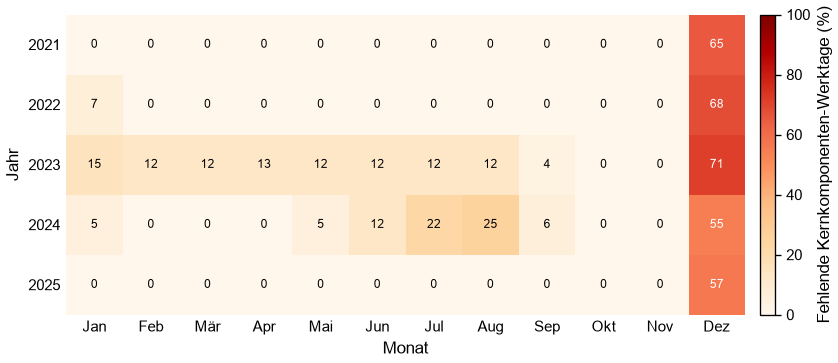

,year,month,expected_component_weekdays,covered_component_weekdays,missing_component_weekdays,missing_pct
0,2021,1,147,147,0,0.0
1,2021,2,140,140,0,0.0
2,2021,3,161,161,0,0.0
3,2021,4,154,154,0,0.0
4,2021,5,147,147,0,0.0
5,2021,6,154,154,0,0.0
6,2021,7,154,154,0,0.0
7,2021,8,154,154,0,0.0
8,2021,9,154,154,0,0.0
9,2021,10,147,147,0,0.0


,target_year,obb_source_year,is_proxy,mvo_station_ids,obb_active_station_ids,obb_new_station_ids,obb_school_departures_added,obb_holiday_departures_added,obb_average_departures_added
0,2021,2023,True,7065,118,45,5466.2,5464.75,5465.475
1,2022,2023,True,6990,118,42,5466.2,5464.75,5465.475
2,2023,2023,False,6978,118,42,5466.2,5464.75,5465.475
3,2024,2024,False,6988,118,41,5680.8,5674.75,5677.775
4,2025,2025,False,7045,118,40,5690.2,5689.00,5689.600


,year,school_rail_departures,school_rail_stations,holiday_rail_departures,holiday_rail_stations,average_rail_departures
0,2017,7668,230,7623,230,7645.5
1,2018,7663,229,7618,229,7640.5
2,2019,7790,234,7727,234,7758.5
3,2020,8086,258,8027,258,8056.5
4,2022,8389,210,8281,207,8335.0


,source,school_weekday_departures,holiday_weekday_departures,equal_weight_average
0,Verkehrsverbund Steiermark,283451.0,227762.00,255606.500
1,Mobilitätsverbünde Österreich,295171.8,242431.75,268801.775


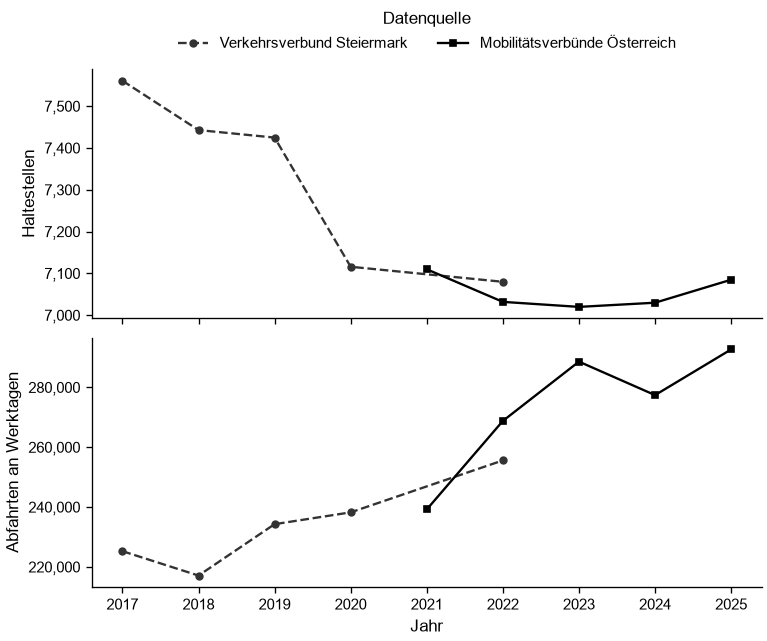

,source,year,stops,weekday_departures
0,Verkehrsverbund Steiermark,2017,7561,225279.000
1,Verkehrsverbund Steiermark,2018,7443,217130.000
2,Verkehrsverbund Steiermark,2019,7425,234303.000
3,Verkehrsverbund Steiermark,2020,7116,238252.000
4,Verkehrsverbund Steiermark,2022,7080,255606.500
5,Mobilitätsverbünde Österreich,2021,7110,239228.550
6,Mobilitätsverbünde Österreich,2022,7032,268801.775
7,Mobilitätsverbünde Österreich,2023,7020,288615.950
8,Mobilitätsverbünde Österreich,2024,7030,277425.250
9,Mobilitätsverbünde Österreich,2025,7085,292697.000


C:\Users\leopo\AppData\Local\Temp\ipykernel_3712\1471853598.py:263: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  removed.plot(ax=axis, color="#B35C37", markersize=5, alpha=0.75, rasterized=True)
C:\Users\leopo\AppData\Local\Temp\ipykernel_3712\1471853598.py:263: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  removed.plot(ax=axis, color="#B35C37", markersize=5, alpha=0.75, rasterized=True)


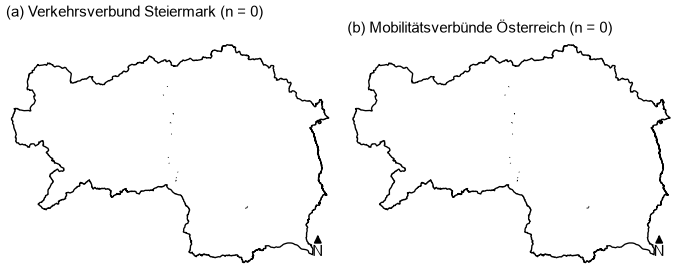

,legacy_stops_before_threshold,gtfs_stops_before_threshold,matching_station_ids,legacy_only_station_ids,gtfs_only_station_ids,legacy_only_school_named,legacy_only_rail_named,legacy_removed_below_one,gtfs_removed_below_one,legacy_shared_departures,gtfs_shared_departures,legacy_only_departures,gtfs_only_departures
0,7080,7032,6895,185,137,5,3,0,0,254410.0,265802.275,1196.5,2999.5


In [63]:
# Rebuild the unfiltered legacy collection so this long cell remains safe to rerun interactively.
legacy_datasets = {year: build_year_dataset(year) for year in VALID_LEGACY_YEARS}
mvo_gtfs_results = {year: build_gtfs_year_dataset(year) for year in GTFS_SOURCE_YEARS}
mvo_gtfs_datasets = {year: result[0] for year, result in mvo_gtfs_results.items()}
obb_gtfs_results = {
    year: build_gtfs_year_dataset(
        year, archive=obb_gtfs_file(year), agency_ids=OBB_AGENCY_IDS, route_id_prefix="OBB:"
    )
    for year in OBB_ARCHIVE_YEARS
}
obb_gtfs_datasets = {year: result[0] for year, result in obb_gtfs_results.items()}


def merge_gtfs_supplement(primary, supplement, year, obb_source_year):
    """Add a separately sourced operator feed without duplicating shared station records."""
    column_order = list(primary.columns)
    primary = primary.set_index("station_id").copy()
    supplement = supplement.set_index("station_id").copy()
    shared_ids = primary.index.intersection(supplement.index)
    new_ids = supplement.index.difference(primary.index)

    for column in ("weekday_school_departures", "weekday_holiday_departures"):
        primary.loc[shared_ids, column] += supplement.loc[shared_ids, column]
    for station_id in shared_ids:
        route_ids = set(filter(None, str(primary.at[station_id, "weekday_route_ids"]).split("|")))
        route_ids.update(filter(None, str(supplement.at[station_id, "weekday_route_ids"]).split("|")))
        primary.at[station_id, "weekday_route_ids"] = "|".join(sorted(route_ids))
        primary.at[station_id, "weekday_line_count"] = len(route_ids)
        primary.at[station_id, "school_source_has_stop"] = bool(
            primary.at[station_id, "school_source_has_stop"] or supplement.at[station_id, "school_source_has_stop"]
        )
        primary.at[station_id, "holiday_source_has_stop"] = bool(
            primary.at[station_id, "holiday_source_has_stop"] or supplement.at[station_id, "holiday_source_has_stop"]
        )

    combined = gpd.GeoDataFrame(
        pd.concat([primary, supplement.loc[new_ids]], axis=0), geometry="geometry", crs=primary.crs
    ).reset_index()
    combined["weekday_avg_departures"] = combined[
        ["weekday_school_departures", "weekday_holiday_departures"]
    ].mean(axis=1)
    combined["year"] = year
    combined["frequency_source_year"] = year
    combined["imputation_method"] = (
        "observed_gtfs_with_obb" if obb_source_year == year else "observed_gtfs_with_obb_2023_proxy"
    )
    assert combined["station_id"].is_unique
    assert combined.loc[combined["station_id"].isin(shared_ids), "geometry"].reset_index(drop=True).equals(
        primary.loc[shared_ids, "geometry"].reset_index(drop=True)
    ), "Primary coordinates changed while adding the ÖBB supplement"
    return combined[column_order].sort_values("station_id").reset_index(drop=True)


gtfs_datasets = {year: dataset.copy() for year, dataset in mvo_gtfs_datasets.items()}
for year in GTFS_SOURCE_YEARS:
    obb_source_year = OBB_SUPPLEMENT_SOURCE_YEAR[year]
    gtfs_datasets[year] = merge_gtfs_supplement(
        mvo_gtfs_datasets[year], obb_gtfs_datasets[obb_source_year], year, obb_source_year
    )

gtfs_coverage = pd.DataFrame([
    {"feed": SOURCE_LABELS["gtfs"], **result[1]} for result in mvo_gtfs_results.values()
] + [
    {"feed": "ÖBB", **result[1]} for result in obb_gtfs_results.values()
])
display(gtfs_coverage)

# Monthly archive-completeness diagnostic. A core component-day is missing when an expected
# operator/mode combination has no valid boarding event at any in-bound stop. Seasonal lifts
# and small school-only operators are intentionally excluded from the stable core.
daily_component_parts = [
    gtfs_daily_component_departures(gtfs_file(year), year, feed="mvo")
    for year in GTFS_SOURCE_YEARS
] + [
    gtfs_daily_component_departures(
        obb_gtfs_file(year), year, feed="obb", agency_ids=OBB_AGENCY_IDS
    )
    for year in OBB_ARCHIVE_YEARS
]
gtfs_daily_components = pd.concat(daily_component_parts, ignore_index=True)

coverage_grids = []
for year in GTFS_SOURCE_YEARS:
    expected_components = [":".join(component) for component in CORE_GTFS_COMPONENTS]
    if year in OBB_ARCHIVE_YEARS:
        expected_components.append("obb:01:2")
    grid = pd.MultiIndex.from_product(
        [pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="B"), expected_components],
        names=["date", "component"],
    ).to_frame(index=False)
    observed = (gtfs_daily_components.loc[gtfs_daily_components["year"].eq(year)]
                .groupby(["date", "component"], as_index=False)["scheduled_departures"].sum())
    grid = grid.merge(observed, on=["date", "component"], how="left", validate="one_to_one")
    grid["scheduled_departures"] = grid["scheduled_departures"].fillna(0)
    grid["covered"] = grid["scheduled_departures"].gt(0)
    grid["year"] = year
    coverage_grids.append(grid)
gtfs_component_coverage = pd.concat(coverage_grids, ignore_index=True)
gtfs_component_coverage["month"] = gtfs_component_coverage["date"].dt.month

gtfs_monthly_coverage = (gtfs_component_coverage.groupby(["year", "month"], as_index=False)
                         .agg(expected_component_weekdays=("covered", "size"),
                              covered_component_weekdays=("covered", "sum")))
gtfs_monthly_coverage["missing_component_weekdays"] = (
    gtfs_monthly_coverage["expected_component_weekdays"]
    - gtfs_monthly_coverage["covered_component_weekdays"]
)
gtfs_monthly_coverage["missing_pct"] = (
    100 * gtfs_monthly_coverage["missing_component_weekdays"]
    / gtfs_monthly_coverage["expected_component_weekdays"]
)
gtfs_monthly_coverage.to_csv(OUTPUT_DIR / "public_transport_gtfs_monthly_coverage.csv", index=False)

representative_period_rows = []
for year, periods in GTFS_REPRESENTATIVE_DATES.items():
    for period, dates in periods.items():
        selected = gtfs_component_coverage.loc[
            gtfs_component_coverage["year"].eq(year)
            & gtfs_component_coverage["date"].isin(pd.to_datetime(dates))
        ]
        representative_period_rows.append({
            "year": year, "period": period, "dates": "|".join(dates),
            "expected_component_weekdays": len(selected),
            "covered_component_weekdays": int(selected["covered"].sum()),
            "coverage_pct": 100 * selected["covered"].mean(),
        })
gtfs_representative_period_validation = pd.DataFrame(representative_period_rows)
assert gtfs_representative_period_validation["coverage_pct"].eq(100).all(), (
    "A representative period contains a missing core operator/mode component"
)
gtfs_representative_period_validation.to_csv(
    OUTPUT_DIR / "public_transport_gtfs_representative_period_validation.csv", index=False
)
display(gtfs_representative_period_validation)

coverage_matrix = gtfs_monthly_coverage.pivot(index="year", columns="month", values="missing_pct")
coverage_matrix = coverage_matrix.reindex(index=GTFS_SOURCE_YEARS, columns=range(1, 13))
fig, axis = plt.subplots(figsize=(7.2, 3.2))
image = axis.imshow(coverage_matrix, cmap="OrRd", vmin=0, vmax=100, aspect="auto")
month_labels = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun", "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]
axis.set(xticks=range(12), xticklabels=month_labels, yticks=range(len(GTFS_SOURCE_YEARS)),
         yticklabels=GTFS_SOURCE_YEARS, xlabel="Monat", ylabel="Jahr")
for row in range(coverage_matrix.shape[0]):
    for column in range(coverage_matrix.shape[1]):
        value = coverage_matrix.iloc[row, column]
        axis.text(column, row, f"{value:.0f}", ha="center", va="center", fontsize=7,
                  color="white" if value >= 45 else "black")
colorbar = fig.colorbar(image, ax=axis, fraction=0.035, pad=0.02)
colorbar.set_label("Fehlende Kernkomponenten-Werktage (%)")
axis.spines[:].set_visible(False)
axis.tick_params(length=0)
fig.tight_layout()
save_apa7(fig, FIGURE_DIR / "figure_4d_gtfs_monthly_missing_data.png")
save_apa7(fig, FIGURE_DIR / "figure_4d_gtfs_monthly_missing_data.svg")
plt.show()
display(gtfs_monthly_coverage.round({"missing_pct": 1}))

obb_supplement_rows = []
for target_year, obb_source_year in OBB_SUPPLEMENT_SOURCE_YEAR.items():
    supplement = obb_gtfs_datasets[obb_source_year]
    active_supplement = supplement.loc[supplement["weekday_avg_departures"].gt(0)]
    obb_supplement_rows.append({
        "target_year": target_year,
        "obb_source_year": obb_source_year,
        "is_proxy": obb_source_year != target_year,
        "mvo_station_ids": mvo_gtfs_datasets[target_year]["station_id"].nunique(),
        "obb_active_station_ids": int(active_supplement["station_id"].nunique()),
        "obb_new_station_ids": len(
            set(active_supplement["station_id"]) - set(mvo_gtfs_datasets[target_year]["station_id"])
        ),
        "obb_school_departures_added": supplement["weekday_school_departures"].sum(),
        "obb_holiday_departures_added": supplement["weekday_holiday_departures"].sum(),
        "obb_average_departures_added": supplement["weekday_avg_departures"].sum(),
    })
obb_supplement_validation = pd.DataFrame(obb_supplement_rows)
display(obb_supplement_validation)
obb_supplement_validation.to_csv(OUTPUT_DIR / "public_transport_obb_supplement_validation.csv", index=False)

legacy_rail_rows = []
legacy_rail_pattern = r"S-Bahn|^Zug|nightjet|Vlak"
for year in VALID_LEGACY_YEARS:
    row = {"year": year}
    for day_type, label in (("Schule", "school"), ("Ferien", "holiday")):
        lines = read_frequency_csv(source_file(year, day_type, table_number=2))
        rail = lines.loc[
            lines["Verkehrsmitteltext"].astype("string").str.contains(
                legacy_rail_pattern, case=False, regex=True, na=False
            )
        ].copy()
        row[f"{label}_rail_departures"] = pd.to_numeric(rail["Anzahl Abfahrten"], errors="coerce").sum()
        row[f"{label}_rail_stations"] = rail["EFA-Haltestellennummer"].nunique()
    row["average_rail_departures"] = (row["school_rail_departures"] + row["holiday_rail_departures"]) / 2
    legacy_rail_rows.append(row)
legacy_rail_validation = pd.DataFrame(legacy_rail_rows)
legacy_rail_validation.to_csv(OUTPUT_DIR / "public_transport_legacy_rail_validation.csv", index=False)
display(legacy_rail_validation)

unfiltered_source_collections = {"legacy": legacy_datasets, "gtfs": gtfs_datasets}
excluded_low_frequency = {
    (source, year): dataset.loc[dataset["weekday_avg_departures"].lt(MIN_WEEKDAY_DEPARTURES)].copy()
    for source, collection in unfiltered_source_collections.items()
    for year, dataset in collection.items()
}
legacy_datasets = {
    year: dataset.loc[dataset["weekday_avg_departures"].ge(MIN_WEEKDAY_DEPARTURES)].copy()
    for year, dataset in legacy_datasets.items()
}
gtfs_datasets = {
    year: dataset.loc[dataset["weekday_avg_departures"].ge(MIN_WEEKDAY_DEPARTURES)].copy()
    for year, dataset in gtfs_datasets.items()
}

comparison_summary = pd.DataFrame([
    {"source": source, "year": year, "stops": len(dataset),
     "weekday_departures": dataset["weekday_avg_departures"].sum()}
    for source, collection in ((SOURCE_LABELS["legacy"], legacy_datasets), (SOURCE_LABELS["gtfs"], gtfs_datasets))
    for year, dataset in sorted(collection.items())
])
day_type_comparison = pd.DataFrame([
    {
        "source": source,
        "school_weekday_departures": dataset["weekday_school_departures"].sum(),
        "holiday_weekday_departures": dataset["weekday_holiday_departures"].sum(),
        "equal_weight_average": dataset["weekday_avg_departures"].sum(),
    }
    for source, dataset in ((SOURCE_LABELS["legacy"], legacy_datasets[2022]), (SOURCE_LABELS["gtfs"], gtfs_datasets[2022]))
])
display(day_type_comparison)

from matplotlib.ticker import StrMethodFormatter
fig, (ax_stops, ax_departures) = plt.subplots(
    2, 1, figsize=(7.2, 5.6), sharex=True, gridspec_kw={"hspace": 0.08}
)
source_styles = {
    SOURCE_LABELS["legacy"]: {"color": "0.20", "linestyle": "--", "marker": "o"},
    SOURCE_LABELS["gtfs"]: {"color": "#000000", "linestyle": "-", "marker": "s"},
}
for source, source_data in comparison_summary.groupby("source", sort=False):
    style = source_styles[source]
    ax_stops.plot(source_data["year"], source_data["stops"], label=source, linewidth=1.4, markersize=4, **style)
    ax_departures.plot(source_data["year"], source_data["weekday_departures"], label=source, linewidth=1.4, markersize=4, **style)
for axis, ylabel in ((ax_stops, "Haltestellen"), (ax_departures, "Abfahrten an Werktagen")):
    axis.set_ylabel(ylabel)
    axis.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(False)
ax_stops.legend(title="Datenquelle", loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
ax_departures.set(xticks=range(2017, 2026), xlabel="Jahr")
save_apa7(fig, FIGURE_DIR / "figure_4b_stops_and_weekday_departures_stacked.png")
save_apa7(fig, FIGURE_DIR / "figure_4b_stops_and_weekday_departures_stacked.svg")
plt.show()
display(comparison_summary)

# Figure 7c: stops removed by the common <1 average weekday-departure rule in the overlap year.
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.4), sharex=True, sharey=True)
boundary_series = gpd.GeoSeries([styria_boundary], crs="EPSG:3857")
map_xmin, map_ymin, map_xmax, map_ymax = boundary_series.total_bounds
map_padding = 5_000
for panel, (axis, source) in enumerate(zip(axes, ("legacy", "gtfs"))):
    label = SOURCE_LABELS[source]
    removed = excluded_low_frequency[(source, 2022)]
    boundary_series.boundary.plot(ax=axis, color="black", linewidth=0.8)
    removed.plot(ax=axis, color="#B35C37", markersize=5, alpha=0.75, rasterized=True)
    axis.set_title(f"({chr(97 + panel)}) {label} (n = {len(removed):,})", loc="left", fontsize=9, pad=4)
    axis.set(xlim=(map_xmin - map_padding, map_xmax + map_padding),
             ylim=(map_ymin - map_padding, map_ymax + map_padding))
    axis.set_aspect("equal")
    axis.set_axis_off()
    add_north_arrow(axis)
fig.subplots_adjust(wspace=0.04)
save_apa7(fig, FIGURE_DIR / "figure_7c_excluded_low_frequency_stops_2022.png")
save_apa7(fig, FIGURE_DIR / "figure_7c_excluded_low_frequency_stops_2022.svg")
plt.show()

legacy_2022_raw = unfiltered_source_collections["legacy"][2022]
gtfs_2022_raw = unfiltered_source_collections["gtfs"][2022]
legacy_ids, gtfs_ids = set(legacy_2022_raw["station_id"]), set(gtfs_2022_raw["station_id"])
shared_ids = legacy_ids & gtfs_ids
legacy_only = legacy_2022_raw.loc[legacy_2022_raw["station_id"].isin(legacy_ids - gtfs_ids)]
gtfs_only = gtfs_2022_raw.loc[gtfs_2022_raw["station_id"].isin(gtfs_ids - legacy_ids)]
school_name_pattern = r"schul|gymnasium|volksschule|mittelschule|htl|hak|internat"
rail_name_pattern = r"bahnhof|bahnhst"
overlap_diagnostics = pd.DataFrame([{
    "legacy_stops_before_threshold": len(legacy_2022_raw),
    "gtfs_stops_before_threshold": len(gtfs_2022_raw),
    "matching_station_ids": len(shared_ids),
    "legacy_only_station_ids": len(legacy_only),
    "gtfs_only_station_ids": len(gtfs_only),
    "legacy_only_school_named": int(legacy_only["station_name"].str.contains(school_name_pattern, case=False, regex=True, na=False).sum()),
    "legacy_only_rail_named": int(legacy_only["station_name"].str.contains(rail_name_pattern, case=False, regex=True, na=False).sum()),
    "legacy_removed_below_one": len(excluded_low_frequency[("legacy", 2022)]),
    "gtfs_removed_below_one": len(excluded_low_frequency[("gtfs", 2022)]),
    "legacy_shared_departures": legacy_2022_raw.loc[legacy_2022_raw["station_id"].isin(shared_ids), "weekday_avg_departures"].sum(),
    "gtfs_shared_departures": gtfs_2022_raw.loc[gtfs_2022_raw["station_id"].isin(shared_ids), "weekday_avg_departures"].sum(),
    "legacy_only_departures": legacy_only["weekday_avg_departures"].sum(),
    "gtfs_only_departures": gtfs_only["weekday_avg_departures"].sum(),
}])
display(overlap_diagnostics)

source_collections = {"legacy": legacy_datasets, "gtfs": gtfs_datasets}
datasets = {}
for target_year, (source, source_year, method) in YEAR_ASSIGNMENTS.items():
    dataset = source_collections[source][source_year].copy()
    dataset["year"] = target_year
    dataset["frequency_source_year"] = source_year
    dataset["imputation_method"] = method
    for column in ("year", "frequency_source_year", "station_id", "efa_stop_id", "weekday_line_count"):
        dataset[column] = pd.to_numeric(dataset[column], errors="raise").astype("int64")
    for column in ("weekday_school_departures", "weekday_holiday_departures", "weekday_avg_departures", "x_web_mercator", "y_web_mercator"):
        dataset[column] = pd.to_numeric(dataset[column], errors="raise").astype("float64")
    for column in ("global_id", "station_name", "station_name_location_file", "weekday_route_ids", "imputation_method"):
        dataset[column] = dataset[column].astype("string")
    for column in ("school_source_has_stop", "holiday_source_has_stop", "location_matched"):
        dataset[column] = dataset[column].astype(bool)
    datasets[target_year] = dataset


### Findings on the apparent source gap

The large original discrepancy was caused by incomplete date coverage and the omitted ÖBB feed, not by stop count. Before the common frequency threshold, the 2022 legacy and supplemented GTFS sources contain 7,080 and 7,032 in-bound station IDs respectively. They share 6,895 IDs; 185 occur only in the legacy extract and 137 only in GTFS. Of the 185 legacy-only names, only five contain an explicit school-related term and only three contain `Bahnhof`/`Bahnhst`. Adding the 2023 ÖBB proxy to 2022 therefore resolves nearly all of the formerly rail-heavy legacy-only set and provides no evidence of a large block of school-bus stops.

The former GTFS calculation produced a roughly 50,000–60,000 departure deficit because it averaged dates for which parts of an archived static feed were incomplete and lacked ÖBB-operated trains. The revised comparison uses five complete school weekdays immediately before the Austrian autumn break, five official school-free weekdays in the following autumn-holiday period, and the earliest available 2023 ÖBB archive as a documented proxy. After the common threshold, the 2022 totals are 255,513.0 legacy versus 255,623.8 supplemented GTFS average weekday departures, with 6,893 versus 6,644 stops. The average departure totals now differ by only 110.8 (0.04%). Before thresholding, the 6,895 shared IDs have 254,410.0 legacy versus 252,776.8 GTFS departures; source-exclusive stops offset this difference with 1,196.5 legacy versus 3,015.7 GTFS departures.

The day-type audit provides an additional cross-check. The supplemented 2022 GTFS school-period total is 294,877.4 departures, 11,612.4 above the legacy school extract; its autumn-holiday total is 216,370.2, 11,390.8 below the legacy holiday extract. These nearly symmetric differences cancel in the equal-weight mean. The two sources still use different official holiday periods—the legacy archive used 24 February 2022 during Styria's semester holiday—so the close final average should not be interpreted as exact historical agreement for each day type. The common one-departure threshold removes 187 legacy and 388 GTFS station records in 2022; retaining GTFS `pickup_type = 1` records would incorrectly count stops where boarding is prohibited.

GTFS semantics require `stop_times.txt` to be linked to `trips.txt` and the service calendars, and define `pickup_type = 1` as no pickup; those records are excluded here ([GTFS Schedule Reference](https://gtfs.org/documentation/schedule/reference/)). The representative dates follow Austria's officially published autumn holidays and generally school-free days ([2020/21 holidays](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/ferientermine_20_21.html), [2021/22 holidays](https://www.bmb.gv.at/dam/jcr%3A6cd23c89-cb44-4e56-a7c2-6edb7786b3c9/ferientermine_21_22.pdf), [2022/23 holidays](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/ferientermine_22_23.html), [2023/24 holidays](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/ferientermine_23_24.html), [2024/25 holidays](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/ferientermine_24_25.html), [2025/26 holidays](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/ferientermine_25_26.html), [school-free days](https://www.bmb.gv.at/Themen/schule/schulpraxis/termine/feiertage.html)). Individual schools may differ from the national dates. Figure 4d reports the share of expected core operator/mode weekdays with zero valid in-bound boarding events. It evaluates only the year-specific archives, so the 2023 ÖBB proxy is not misrepresented as observed monthly coverage in 2021 or 2022. The figure shows 0% missing core coverage in October and November for every year. The large December values arise because the archived feeds end partway through the month; the 2023 early-year gap and 2024 summer gap are also visible. These incomplete periods are therefore not used for annual frequencies. Geometry checks are independent of the IDs: all retained records intersect the dissolved Styria boundary. Nine points in the legacy master location workbook lie outside and are removed; one parsed ÖBB point in 2025 lies outside and is removed.

### ÖBB supplement audit

The separate ÖBB feeds confirm a real omission from the primary MVO GTFS source. Restricting the national archives to ÖBB Personenverkehr agency `01` adds 5,251.9 average weekday departures from the 2023 archive, 5,499.7 from 2024, and 5,689.6 from 2025. The earliest available 2023 value is reused without temporal adjustment for 2021 and 2022 and is explicitly marked as a proxy in both `OBB_SUPPLEMENT_SOURCE_YEAR`, `imputation_method`, and the validation CSV. It adds 45 station IDs absent from the 2021 MVO layer and 42 absent from the 2022 layer. Shared IDs are merged rather than appended, so their station record is not duplicated. The primary feed's rail service is operated by Graz-Köflacher Bahn and Steiermarkbahn, while the supplement is restricted to ÖBB; the `OBB:` route namespace prevents route-key collisions. The legacy line-level extracts explicitly contain train modes (`S-Bahn`, `Zug`, and named train categories), averaging about 7,646 rail departures in 2017 and 8,335 in 2022. This supports supplementing the otherwise missing ÖBB service, while the proxy label preserves the unavoidable uncertainty for 2021–2022.


## Inspect and export the final annual layers


In [64]:
assert set(datasets) == set(ANALYSIS_YEARS)
validation = pd.DataFrame([
    {
        "year": year,
        "frequency_source_year": int(dataset["frequency_source_year"].iloc[0]),
        "imputation_method": dataset["imputation_method"].iloc[0],
        "excluded_below_one_departure": len(excluded_low_frequency[(YEAR_ASSIGNMENTS[year][0], YEAR_ASSIGNMENTS[year][1])]),
        "frequency_stops": len(dataset),
        "coordinate_matches": int(dataset["location_matched"].sum()),
        "unmatched_coordinates": int((~dataset["location_matched"]).sum()),
        "missing_station_names": int(dataset["station_name"].isna().sum()),
    }
    for year, dataset in sorted(datasets.items())
])

summary = pd.DataFrame([
    {
        "year": year,
        "stops": len(dataset),
        "located_stops": int(dataset["location_matched"].sum()),
        "total_avg_departures": dataset["weekday_avg_departures"].sum(),
        "median_avg_departures": dataset["weekday_avg_departures"].median(),
        "median_weekday_line_count": dataset["weekday_line_count"].median(),
        "max_weekday_line_count": dataset["weekday_line_count"].max(),
    }
    for year, dataset in sorted(datasets.items())
])

for year, dataset in datasets.items():
    assert dataset.geometry.notna().all(), f"{year} contains stops without coordinates"
    assert dataset.geometry.intersects(styria_boundary).all(), f"{year} contains stops outside Styria"
    assert dataset["weekday_avg_departures"].ge(MIN_WEEKDAY_DEPARTURES).all(), f"{year} contains sub-threshold stops"
    dataset.to_parquet(OUTPUT_DIR / f"public_transport_weekday_stop_frequency_{year}.geoparquet", index=False)

validation.to_csv(OUTPUT_DIR / "public_transport_weekday_frequency_validation.csv", index=False)
summary.to_csv(OUTPUT_DIR / "public_transport_weekday_frequency_summary.csv", index=False)

comparison_columns = [column for column in datasets[2017].columns if column not in {"year", "frequency_source_year", "imputation_method"}]
pd.testing.assert_frame_equal(datasets[2015][comparison_columns], datasets[2017][comparison_columns])
pd.testing.assert_frame_equal(datasets[2016][comparison_columns], datasets[2017][comparison_columns])

display(validation)
display(summary)
display(datasets[2016].head())
display(datasets[2016][["weekday_school_departures", "weekday_holiday_departures", "weekday_avg_departures", "weekday_line_count"]].describe().round(2))


,year,frequency_source_year,imputation_method,excluded_below_one_departure,frequency_stops,coordinate_matches,unmatched_coordinates,missing_station_names
0,2015,2017,full_2017_proxy,0,7561,7561,0,0
1,2016,2017,full_2017_proxy,0,7561,7561,0,0
2,2017,2017,observed_legacy,0,7561,7561,0,0
3,2018,2018,observed_legacy,0,7443,7443,0,0
4,2019,2019,observed_legacy,0,7425,7425,0,0
5,2020,2020,observed_legacy,0,7116,7116,0,0
6,2021,2021,observed_gtfs_with_obb_2023_proxy,0,7110,7110,0,0
7,2022,2022,observed_gtfs_with_obb_2023_proxy,0,7032,7032,0,0
8,2023,2023,observed_gtfs_with_obb,0,7020,7020,0,0
9,2024,2024,observed_gtfs_with_obb,0,7030,7030,0,0


,year,stops,located_stops,total_avg_departures,median_avg_departures,median_weekday_line_count,max_weekday_line_count
0,2015,7561,7561,225279.000,7.0,1.0,67
1,2016,7561,7561,225279.000,7.0,1.0,67
2,2017,7561,7561,225279.000,7.0,1.0,67
3,2018,7443,7443,217130.000,7.0,1.0,57
4,2019,7425,7425,234303.000,7.0,1.0,59
5,2020,7116,7116,238252.000,8.5,1.0,60
6,2021,7110,7110,239228.550,8.0,1.0,128
7,2022,7032,7032,268801.775,10.0,1.0,124
8,2023,7020,7020,288615.950,10.5,1.0,139
9,2024,7030,7030,277425.250,10.5,1.0,74


,year,frequency_source_year,imputation_method,station_id,efa_stop_id,global_id,station_name,station_name_location_file,weekday_school_departures,weekday_holiday_departures,weekday_avg_departures,weekday_line_count,weekday_route_ids,school_source_has_stop,holiday_source_has_stop,location_matched,x_web_mercator,y_web_mercator,geometry
0,2016,2017,full_2017_proxy,1,63200001,at:46:1,Voitsberg Josefskirche,Voitsberg Josefskirche,60.0,48.0,54.0,4,86700_|86702_|86705_|86710_,True,True,True,1685862.0,5950405.0,POINT (1685862 5950405)
1,2016,2017,full_2017_proxy,2,63200002,at:46:2,Voitsberg Hauptplatz,Voitsberg Hauptplatz,91.0,63.0,77.0,7,09713_|09718_|86700_|86702_|86705_|86710_|86727a,True,True,True,1686518.0,5950126.0,POINT (1686518 5950126)
2,2016,2017,full_2017_proxy,4,63200004,at:46:4,Arnstein Gustibar,Arnstein Gustibar,4.0,0.0,2.0,1,01717_,True,False,True,1686924.0,5948687.0,POINT (1686924 5948687)
3,2016,2017,full_2017_proxy,5,63200005,at:46:5,Arnstein Koppn Kapelle,Arnstein Koppn Kapelle,5.0,0.0,2.5,1,01717_,True,False,True,1688678.0,5947287.0,POINT (1688678 5947287)
4,2016,2017,full_2017_proxy,8,63200008,at:46:8,Arnstein ehemaliges Gemeindeamt,Arnstein ehemaliges Gemeindeamt,5.0,0.0,2.5,1,01717_,True,False,True,1688745.0,5946436.0,POINT (1688745 5946436)


,weekday_school_departures,weekday_holiday_departures,weekday_avg_departures,weekday_line_count
count,7561.00,7561.00,7561.00,7561.00
mean,32.65,26.94,29.79,1.85
std,88.13,81.91,83.74,2.32
min,0.00,0.00,0.50,1.00
25%,4.00,0.00,2.50,1.00
50%,10.00,4.00,7.00,1.00
75%,25.00,18.00,21.50,2.00
max,2588.00,2250.00,2419.00,67.00


## Interactive station maps and Figure 7a source comparison

Set `MAP_YEAR` to one of the generated source years for the single-year map. The second Leaflet map is Figure 7a: it overlays both available 2022 source extracts as separately switchable layers, with a `Datenquelle` legend and source-specific colors. Tooltips report source, station name, and average weekday departures. The resulting HTML files are standalone apart from the web map tiles.

In [65]:
import json

import folium

MAP_YEAR = 2025
MAP_OUTPUT_DIR = Path("FIG/Haltestellen")
MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

map_path = OUTPUT_DIR / f"public_transport_weekday_stop_frequency_{MAP_YEAR}.geoparquet"
map_stops = gpd.read_parquet(map_path).dropna(subset=["geometry"]).to_crs("EPSG:4326")
map_stops = map_stops[["station_id", "station_name", "weekday_avg_departures", "weekday_line_count", "geometry"]].copy()
map_center = [map_stops.geometry.y.median(), map_stops.geometry.x.median()]

station_map = folium.Map(location=map_center, zoom_start=8, tiles="CartoDB positron", control_scale=True)
folium.GeoJson(
    data=json.loads(map_stops.to_json()),
    name=f"Public-transport stations {MAP_YEAR}",
    marker=folium.CircleMarker(radius=3, color="#1f4e79", weight=1, fill=True, fill_opacity=0.75),
    tooltip=folium.GeoJsonTooltip(
        fields=["station_name", "weekday_line_count", "weekday_avg_departures"],
        aliases=["Station:", "Weekday lines:", "Average weekday departures:"],
        localize=True,
    ),
    popup=folium.GeoJsonPopup(
        fields=["station_id", "station_name", "weekday_line_count", "weekday_avg_departures"],
        aliases=["Station ID:", "Station:", "Weekday lines:", "Average weekday departures:"],
        localize=True,
    ),
).add_to(station_map)
folium.LayerControl().add_to(station_map)

map_output = MAP_OUTPUT_DIR / f"public_transport_stations_{MAP_YEAR}_interactive.html"
station_map.save(map_output)
print(f"Mapped {len(map_stops):,} stations and wrote {map_output}")

# Figure 7a: interactive like-for-like comparison of the two sources in their overlap year.
COMPARISON_YEAR = 2022
comparison_sources = [
    (SOURCE_LABELS["legacy"], legacy_datasets[COMPARISON_YEAR], "#B35C37", 5),
    (SOURCE_LABELS["gtfs"], gtfs_datasets[COMPARISON_YEAR], "#23658B", 3),
]
comparison_center = [
    municipality_boundaries.to_crs("EPSG:4326").geometry.union_all().centroid.y,
    municipality_boundaries.to_crs("EPSG:4326").geometry.union_all().centroid.x,
]
comparison_map = folium.Map(location=comparison_center, zoom_start=8, tiles="CartoDB positron", control_scale=True)
for source_label, source_data, color, radius in comparison_sources:
    layer_data = source_data[["station_id", "station_name", "weekday_avg_departures", "geometry"]].copy()
    layer_data = layer_data.to_crs("EPSG:4326")
    layer_data["Datenquelle"] = source_label
    layer_data["weekday_avg_departures"] = layer_data["weekday_avg_departures"].round(1)
    folium.GeoJson(
        data=json.loads(layer_data.to_json()),
        name=source_label,
        marker=folium.CircleMarker(
            radius=radius, color=color, weight=1.5, fill=True, fill_color=color, fill_opacity=0.65
        ),
        tooltip=folium.GeoJsonTooltip(
            fields=["Datenquelle", "station_name", "weekday_avg_departures"],
            aliases=["Datenquelle:", "Haltestelle:", "Durchschnittliche Werktagsabfahrten:"],
            localize=True,
        ),
        popup=folium.GeoJsonPopup(
            fields=["Datenquelle", "station_id", "station_name", "weekday_avg_departures"],
            aliases=["Datenquelle:", "Haltestellen-ID:", "Haltestelle:", "Durchschnittliche Werktagsabfahrten:"],
            localize=True,
        ),
        show=True,
    ).add_to(comparison_map)
folium.LayerControl(collapsed=False).add_to(comparison_map)
comparison_map.get_root().html.add_child(folium.Element(f"""
<div style="position:fixed; bottom:28px; left:28px; z-index:9999; background:white;
            border:1px solid #777; border-radius:3px; padding:9px 12px; font-size:13px;">
  <strong>Datenquelle</strong><br>
  <span style="color:#B35C37; font-size:18px;">●</span> {SOURCE_LABELS['legacy']}<br>
  <span style="color:#23658B; font-size:18px;">●</span> {SOURCE_LABELS['gtfs']}
</div>
"""))
comparison_map_output = MAP_OUTPUT_DIR / "figure_7a_public_transport_sources_2022_interactive.html"
comparison_map.save(comparison_map_output)
print(f"Wrote interactive 2022 source comparison to {comparison_map_output}")


Mapped 7,085 stations and wrote FIG\Haltestellen\public_transport_stations_2025_interactive.html
Wrote interactive 2022 source comparison to FIG\Haltestellen\figure_7a_public_transport_sources_2022_interactive.html


## Interactive comparison map for all available years from 2017 onward

Each available annual stop layer is an independent overlay in the Leaflet layer control. Use the checkboxes in the upper-right corner to show or hide years and compare whether missing stops reflect the source data or actual network changes. The newest year is visible by default; all earlier years start hidden to keep the map readable.


In [66]:
COMPARISON_YEARS = sorted(year for year in datasets if year >= 2017)
COMPARISON_OUTPUT = MAP_OUTPUT_DIR / "public_transport_stations_2017_onwards_interactive.html"
YEAR_COLORS = {
    2017: "#0072B2",
    2018: "#E69F00",
    2019: "#009E73",
    2020: "#D55E00",
    2022: "#CC79A7",
    2025: "#000000",
}

comparison_layers = {}
for year in COMPARISON_YEARS:
    year_stops = datasets[year].dropna(subset=["geometry"]).to_crs("EPSG:4326")
    year_stops = year_stops[[
        "year", "station_id", "station_name",
        "weekday_avg_departures", "weekday_line_count", "geometry",
    ]].copy()
    comparison_layers[year] = year_stops

latest_year = max(COMPARISON_YEARS)
latest_stops = comparison_layers[latest_year]
comparison_center = [latest_stops.geometry.y.median(), latest_stops.geometry.x.median()]

comparison_map = folium.Map(
    location=comparison_center,
    zoom_start=8,
    tiles="CartoDB positron",
    control_scale=True,
)

for year, year_stops in comparison_layers.items():
    color = YEAR_COLORS.get(year, "#666666")
    year_group = folium.FeatureGroup(
        name=f"{year} ({len(year_stops):,} stops)",
        overlay=True,
        show=(year == latest_year),
    ).add_to(comparison_map)
    folium.GeoJson(
        data=json.loads(year_stops.to_json()),
        marker=folium.CircleMarker(
            radius=3, color=color, weight=1, fill=True, fill_color=color, fill_opacity=0.75
        ),
        tooltip=folium.GeoJsonTooltip(
            fields=["year", "station_name", "weekday_line_count", "weekday_avg_departures"],
            aliases=["Year:", "Station:", "Weekday lines:", "Average weekday departures:"],
            localize=True,
        ),
        popup=folium.GeoJsonPopup(
            fields=["year", "station_id", "station_name", "weekday_line_count", "weekday_avg_departures"],
            aliases=["Year:", "Station ID:", "Station:", "Weekday lines:", "Average weekday departures:"],
            localize=True,
        ),
    ).add_to(year_group)

folium.LayerControl(collapsed=False).add_to(comparison_map)
comparison_map.save(COMPARISON_OUTPUT)

mapped_stops = sum(len(year_stops) for year_stops in comparison_layers.values())
print(
    f"Mapped {mapped_stops:,} station-year records for {COMPARISON_YEARS} "
    f"and wrote {COMPARISON_OUTPUT}"
)


Mapped 64,822 station-year records for [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025] and wrote FIG\Haltestellen\public_transport_stations_2017_onwards_interactive.html
